# ECMM422J Coursework 1: ECG Heartbeat Classification with a 1D CNN

**Author:**  Arush Kumar Vishwakarma
**Student ID:** 

## Overview
This notebook builds a 1D Convolutional Neural Network to classify ECG heartbeats from the MIT-BIH Arrhythmia dataset into five categories: Normal, Supraventricular, Ventricular, Fusion, and Unknown/Paced.

The pipeline runs in 9 stages:
1. Setup & reproducibility
2. Load data
3. Preprocessing
4. Visualisation
5. Model architecture
6. Class weight calculation
7. K-fold cross-validation + hyperparameter search
8. Final training
9. Evaluation
10. Advanced Evaluation Visualisations
11. Architecture Comparison and Ablation Study

---
## Stage 1: Setup and Reproducibility

Import libraries and lock random seeds so the experiment produces identical results every time.

In [5]:
# Stage 1: Setup and Reproducibility

# Standard library
import os
import random
import json
import time

# Numerical and data libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning library
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical, plot_model

# Classical ML utilities from scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# ---- Reproducibility: lock random seeds ----
# Without this, every training run gives slightly different numbers
# because weight initialisation, data shuffling, and dropout are random.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Plot styling ----
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# ---- Confirm environment ----
print('TensorFlow version:', tf.__version__)
print('Devices available:', tf.config.list_physical_devices())
print('Seed locked to:', SEED)

TensorFlow version: 2.10.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed locked to: 42


---
## Stage 2: Load the Data

The training and test sets are provided as separate CSV files. Each row is one heartbeat:
the first 187 columns are time-domain ECG samples (already normalised to ~[0,1] by the
dataset authors), and the last column is the integer class label in {0, 1, 2, 3, 4}.

No header row, so we pass `header=None` to pandas.

In [6]:
# Stage 2: Load the training and test data

# File paths - data/ folder sits next to the notebook
TRAIN_PATH = 'data/mitbih_train.csv'
TEST_PATH  = 'data/mitbih_test.csv'

# Read both CSVs. header=None because the files have no column names.
t0 = time.time()
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH,  header=None)
print(f'Loaded both CSVs in {time.time() - t0:.1f}s')

# Split each DataFrame into features (X) and label (y).
# .iloc[:, :-1] = "all rows, all columns except the last" = the 187 features
# .iloc[:, -1]  = "all rows, the last column only"        = the class label
# .values gives us numpy arrays (faster than DataFrame for ML).
# astype enforces dtypes: float32 for features (TF prefers this), int64 for labels.
X_train = train_df.iloc[:, :-1].values.astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

X_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(np.int64)

# Sanity prints - shapes, label range, value range
print(f'\nShapes:')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}   y_test : {y_test.shape}')

print(f'\nLabel values present (train): {np.unique(y_train)}')
print(f'Label values present (test) : {np.unique(y_test)}')

print(f'\nFeature value range:')
print(f'  Train: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'  Test : [{X_test.min():.3f}, {X_test.max():.3f}]')

Loaded both CSVs in 2.0s

Shapes:
  X_train: (87554, 187)   y_train: (87554,)
  X_test : (21892, 187)   y_test : (21892,)

Label values present (train): [0 1 2 3 4]
Label values present (test) : [0 1 2 3 4]

Feature value range:
  Train: [0.000, 1.000]
  Test : [0.000, 1.000]


---
## Stage 3: Preprocessing

### 3a. Missing values (per class)

The brief requires per-class handling of missing values: if any cell is missing, fill it
with the mean of that column **computed only within the same class**, so we don't blur
class-specific waveform morphology with a global average.

In [7]:
# Stage 3a: Check for and (if needed) impute missing values per class

# Count NaNs in each set
n_missing_train = int(np.isnan(X_train).sum())
n_missing_test  = int(np.isnan(X_test).sum())
print(f'Missing values in X_train: {n_missing_train}')
print(f'Missing values in X_test : {n_missing_test}')

# Per-class mean imputation. Runs only if there are any NaNs to fix.
def impute_per_class(X, y):
    """
    For each class c:
      compute the column-wise mean across that class (ignoring NaN),
      then fill in any NaN values in that class's rows with those means.
    Returns a new array (does not modify the input).
    """
    X = X.copy()
    for c in np.unique(y):
        mask = (y == c)                                 # rows belonging to class c
        col_means = np.nanmean(X[mask], axis=0)         # per-column mean for class c
        # find positions where there's a NaN AND the row is in class c
        rows, cols = np.where(np.isnan(X) & mask[:, None])
        X[rows, cols] = col_means[cols]
    return X

if n_missing_train > 0:
    X_train = impute_per_class(X_train, y_train)
    print(f'After imputation, train NaNs: {int(np.isnan(X_train).sum())}')
else:
    print('No imputation needed for train.')

if n_missing_test > 0:
    X_test = impute_per_class(X_test, y_test)
    print(f'After imputation, test NaNs: {int(np.isnan(X_test).sum())}')
else:
    print('No imputation needed for test.')

Missing values in X_train: 0
Missing values in X_test : 0
No imputation needed for train.
No imputation needed for test.


### 3b. Normalisation check

The dataset authors (Kachuee et al., 2018) pre-normalised each beat by dividing by its
peak amplitude, so values are already in [0, 1]. We confirm this rather than re-scale
(re-scaling already-scaled data introduces unnecessary distortion).

In [8]:
# Stage 3b: Confirm features are in [0, 1] (already normalised by dataset authors)

print('Training set:')
print(f'  min  = {X_train.min():.4f}')
print(f'  max  = {X_train.max():.4f}')
print(f'  mean = {X_train.mean():.4f}')
print(f'  std  = {X_train.std():.4f}')

print('\nTest set:')
print(f'  min  = {X_test.min():.4f}')
print(f'  max  = {X_test.max():.4f}')
print(f'  mean = {X_test.mean():.4f}')
print(f'  std  = {X_test.std():.4f}')

print('\nNo further scaling applied.')

Training set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1743
  std  = 0.2263

Test set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1735
  std  = 0.2256

No further scaling applied.


### 3c. Reshape for Conv1D and one-hot encode labels

Conv1D expects input shape `(batch, timesteps, channels)`, so we reshape from `(N, 187)`
to `(N, 187, 1)`. The trailing `1` is the channel dimension (ECG has a single channel).

For labels, we one-hot encode: class 2 → `[0, 0, 1, 0, 0]`. This pairs with the softmax
output and categorical cross-entropy loss, and tells the model the classes are categorical
rather than ordered.

In [9]:
# Stage 3c: Reshape inputs for Conv1D and one-hot encode labels

NUM_CLASSES = 5
TIMESTEPS = X_train.shape[1]   # 187 — read from data rather than hard-code

# Reshape (N, 187) -> (N, 187, 1) so Conv1D treats each beat as a single-channel signal
X_train = X_train.reshape(-1, TIMESTEPS, 1)
X_test  = X_test.reshape(-1, TIMESTEPS, 1)

# One-hot encode labels: integer class -> 5-element binary vector
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

# Sanity prints
print(f'TIMESTEPS = {TIMESTEPS}')
print(f'NUM_CLASSES = {NUM_CLASSES}')
print()
print(f'X_train reshaped to: {X_train.shape}')
print(f'X_test  reshaped to: {X_test.shape}')
print()
print(f'y_train one-hot: {y_train_oh.shape}')
print(f'y_test  one-hot: {y_test_oh.shape}')
print()
print(f'Example label conversion:')
print(f'  Integer label: {y_train[0]}')
print(f'  One-hot label: {y_train_oh[0]}')

TIMESTEPS = 187
NUM_CLASSES = 5

X_train reshaped to: (87554, 187, 1)
X_test  reshaped to: (21892, 187, 1)

y_train one-hot: (87554, 5)
y_test  one-hot: (21892, 5)

Example label conversion:
  Integer label: 0
  One-hot label: [1. 0. 0. 0. 0.]


---
## Stage 4: Visualisation

### 4a. Class distribution

The dataset is severely imbalanced. Visualising the per-class counts justifies our use of
class weights during training (Stage 6) and explains why overall accuracy alone is a
misleading metric.

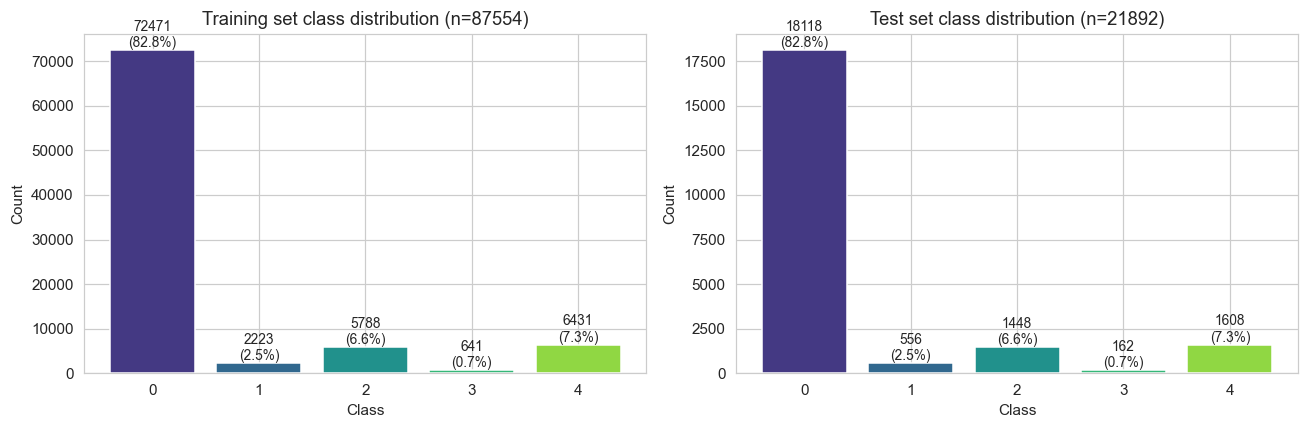

In [10]:
# Stage 4a: Class distribution bar charts (train and test side by side)

class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown/Paced']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y, name in zip(axes, [y_train, y_test], ['Training', 'Test']):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=sns.color_palette('viridis', 5))
    ax.set_title(f'{name} set class distribution (n={len(y)})')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    # annotate each bar with its count and percentage
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, f'{v}\n({100*v/len(y):.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 4b. Representative heartbeat per class

Plotting one beat from each class shows the morphological differences the model must learn:
peak position, secondary deflections, signal duration. These local-in-time patterns are
exactly what 1D convolutions are designed to detect — the justification for choosing a CNN.

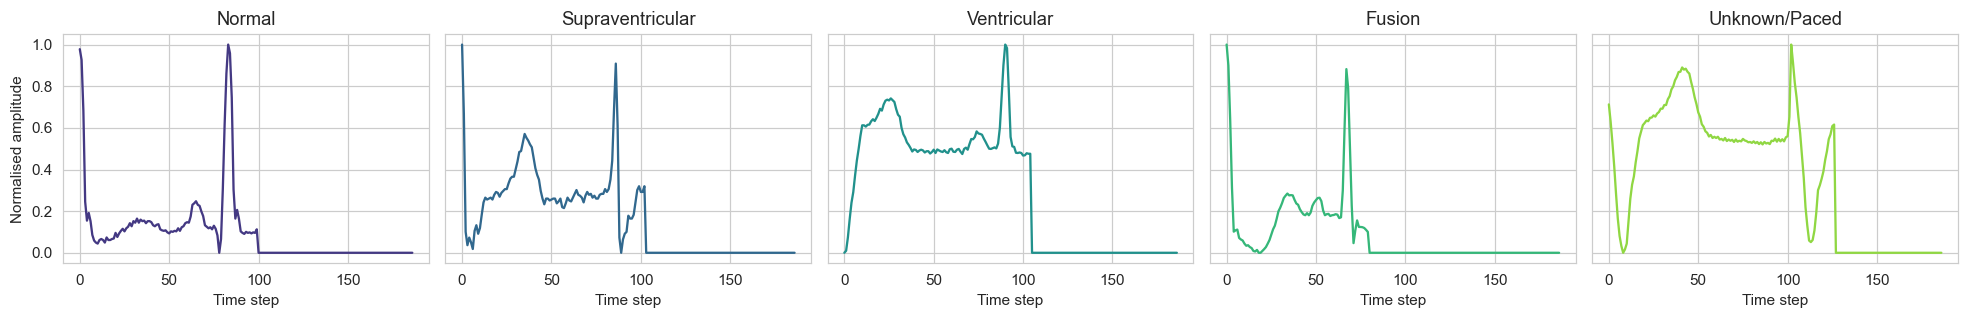

In [11]:
# Stage 4b: Plot one representative beat from each class

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

for c in range(5):
    # find the first sample belonging to class c
    idx = np.where(y_train == c)[0][0]
    # X_train is (N, 187, 1) now, so .squeeze() drops the trailing 1 for plotting
    axes[c].plot(X_train[idx].squeeze(), color=sns.color_palette('viridis', 5)[c])
    axes[c].set_title(class_names[c])
    axes[c].set_xlabel('Time step')

axes[0].set_ylabel('Normalised amplitude')
plt.tight_layout()
plt.savefig('fig_sample_beats.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 5: Model Architecture (1D CNN)

We use a 1D Convolutional Neural Network. ECG beats are time series whose discriminative
features (QRS complex shape, secondary deflections, durations) are *local in time* — exactly
what 1D convolutions capture. This inductive bias makes a CNN more suitable than an MLP
(which ignores temporal order) or an LSTM (slower, with no clear accuracy benefit here for
fixed-length beats).

**Design:** three convolutional blocks (Conv1D → BatchNorm → ReLU → MaxPool → Dropout) with
increasing filter counts (32 → 64 → 128), followed by Global Average Pooling, a dense layer,
and a softmax output. The builder is parameterised so the same code supports the
hyperparameter search in Stage 7.

In [12]:
# Stage 5: Define the 1D CNN architecture

def build_cnn(input_len=187, num_classes=5,
              filters=(32, 64, 128), kernel_size=5,
              dropout=0.3, dense_units=64, learning_rate=1e-3):
    """
    Build and compile a 1D CNN for ECG beat classification.

    Parameters (all tunable in Stage 7's hyperparameter search):
      input_len     : length of the input signal (187)
      num_classes   : number of output classes (5)
      filters       : tuple of filter counts, one per conv block
      kernel_size   : width of each convolutional filter
      dropout       : dropout rate applied after each block and the dense layer
      dense_units   : size of the penultimate dense layer
      learning_rate : Adam optimiser step size
    """
    inputs = layers.Input(shape=(input_len, 1))
    x = inputs

    # Convolutional blocks
    for f in filters:
        x = layers.Conv1D(f, kernel_size=kernel_size, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(dropout)(x)

    # Collapse the time dimension by averaging — fewer params than Flatten + Dense
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Assemble and compile
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',   # pairs with one-hot labels + softmax
        metrics=['accuracy'],
    )
    return model

# Build one instance with default hyperparameters and inspect it
demo_model = build_cnn()
demo_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           192       
                                                                 
 batch_normalization (BatchN  (None, 187, 32)          128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 187, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 32)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 93, 32)            0     

### 5b. Architecture diagram

An auto-generated diagram of the layer structure. (For the final report this is supplemented
with a hand-drawn block diagram showing the data-shape transformations.)

A detailed, publication-quality architecture diagram is generated separately by the accompanying script make_architecture_resnet.py (included in the submission) and is presented in the report. The cell below additionally auto-generates a basic diagram via Keras plot_model for in-notebook reference.

In [13]:
# Stage 5b: Auto-generate an architecture diagram
# Needs graphviz; if it fails, we fall back to the text summary (and draw by hand later).
try:
    plot_model(
        demo_model,
        to_file='fig_architecture_auto.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',     # top-to-bottom; use 'LR' for left-to-right
        dpi=120,
    )
    print('Saved fig_architecture_auto.png')
    from IPython.display import Image
    display(Image('fig_architecture_auto.png'))
except Exception as e:
    print('Could not auto-generate diagram (graphviz not installed?):', e)
    print('No problem — we will hand-draw the architecture figure for the report.')

Could not auto-generate diagram (graphviz not installed?): module 'pydot' has no attribute 'InvocationException'
No problem — we will hand-draw the architecture figure for the report.


In [12]:
demo_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,061 (238.52 KB)

 Trainable params: 60,613 (236.77 KB)

 Non-trainable params: 448 (1.75 KB)

---
## Stage 6: Class Weights for Imbalance

Given the 113× imbalance between the largest (Normal) and smallest (Fusion) classes, an
unweighted model would minimise loss by predicting "Normal" almost everywhere. We weight the
loss inversely with class frequency so errors on rare classes are penalised more heavily.

We apply **square-root tempering** to the standard inverse-frequency weights. The raw weights
(up to ~27× for Fusion) are so aggressive they destabilise early training; the square root
preserves the relative ordering while compressing the dynamic range, giving stable training
that still strongly favours the minority classes.

In [14]:
# Stage 6: Compute square-root-tempered class weights

# Standard "balanced" inverse-frequency weights from sklearn
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)

# Square-root tempering: keep the ordering, compress the range
class_weights = {i: float(np.sqrt(w)) for i, w in enumerate(raw_weights)}

# Show both for comparison (and for the report)
print('Class | Count  | Raw weight | Tempered weight')
print('-' * 50)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
for i in range(NUM_CLASSES):
    print(f'  {i}   | {counts[i]:6d} |   {raw_weights[i]:6.2f}   |     {class_weights[i]:5.2f}')

print('\nclass_weights dict passed to training:')
print(class_weights)

Class | Count  | Raw weight | Tempered weight
--------------------------------------------------
  0   |  72471 |     0.24   |      0.49
  1   |   2223 |     7.88   |      2.81
  2   |   5788 |     3.03   |      1.74
  3   |    641 |    27.32   |      5.23
  4   |   6431 |     2.72   |      1.65

class_weights dict passed to training:
{0: 0.49155358388725223, 1: 2.806617717813582, 2: 1.7393570132743923, 3: 5.226656743811354, 4: 1.650113202508115}


---
## Stage 7: K-Fold Cross-Validation + Hyperparameter Search

We tune hyperparameters using **random search** (more efficient than grid search per
Bergstra & Bengio, 2012), evaluating each configuration with **stratified 5-fold
cross-validation**. Stratification preserves class proportions in every fold, which is
essential under severe imbalance. The configuration with the highest mean validation
accuracy across folds is selected for final training in Stage 8.

In [19]:
# Stage 7a: Define the hyperparameter search space

search_space = {
    'learning_rate': [1e-3, 5e-4, 1e-4],   # Adam step size
    'dropout':       [0.2, 0.3, 0.4],       # regularisation strength
    'kernel_size':   [3, 5, 7],             # width of conv filters
    'batch_size':    [64, 128, 256],        # samples per gradient update
}

# --- Search budget ---
# For a quick test on Mac CPU, set these small (e.g. 1, 2, 2).
# For the real run on Windows GPU, use the full values below.
N_CONFIGS = 12      # number of random configurations to try
N_FOLDS   = 5      # k in k-fold cross-validation
CV_EPOCHS = 12     # epochs per fold during the search

# Sample N_CONFIGS random configurations (reproducible thanks to the seed)
rng = np.random.default_rng(SEED)
def sample_config():
    return {k: rng.choice(v).item() for k, v in search_space.items()}

configs = [sample_config() for _ in range(N_CONFIGS)]
print(f'Search budget: {N_CONFIGS} configs x {N_FOLDS} folds x up to {CV_EPOCHS} epochs')
print(f'\nConfigurations to evaluate:')
for i, c in enumerate(configs):
    print(f'  Config {i}: {c}')

Search budget: 12 configs x 5 folds x up to 12 epochs

Configurations to evaluate:
  Config 0: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128}
  Config 1: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256}
  Config 2: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256}
  Config 3: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256}
  Config 4: {'learning_rate': 0.0005, 'dropout': 0.2, 'kernel_size': 7, 'batch_size': 128}
  Config 5: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 3, 'batch_size': 256}
  Config 6: {'learning_rate': 0.0001, 'dropout': 0.3, 'kernel_size': 5, 'batch_size': 256}
  Config 7: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 5, 'batch_size': 64}
  Config 8: {'learning_rate': 0.001, 'dropout': 0.3, 'kernel_size': 7, 'batch_size': 64}
  Config 9: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 128}
  Config 10:

In [20]:
# Stage 7b: Cross-validation routine for one configuration

def run_cv(config, X, y_int, y_oh, n_folds=5, epochs=12,
           class_weights=None, verbose=0):
    """
    Evaluate one hyperparameter config using stratified k-fold CV.
    Returns: mean val accuracy, std of val accuracy, list of per-fold histories.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_accuracies = []
    fold_histories  = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_int)):
        tf.keras.backend.clear_session()   # free memory between folds

        model = build_cnn(
            input_len=X.shape[1],
            num_classes=NUM_CLASSES,
            kernel_size=int(config['kernel_size']),
            dropout=float(config['dropout']),
            learning_rate=float(config['learning_rate']),
        )

        # stop early if validation loss stops improving (saves time, avoids overfitting)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True)

        history = model.fit(
            X[tr_idx], y_oh[tr_idx],
            validation_data=(X[va_idx], y_oh[va_idx]),
            epochs=epochs,
            batch_size=int(config['batch_size']),
            class_weight=class_weights,
            callbacks=[es],
            verbose=verbose,
        )

        best_val_acc = max(history.history['val_accuracy'])
        fold_accuracies.append(best_val_acc)
        fold_histories.append(history.history)
        print(f'    Fold {fold+1}/{n_folds}: val_acc = {best_val_acc:.4f}')

    return float(np.mean(fold_accuracies)), float(np.std(fold_accuracies)), fold_histories

In [21]:
# Stage 7c: Run the random search (THE SLOW PART — use Windows GPU for the full run)

results = []
search_start = time.time()

for i, cfg in enumerate(configs):
    print(f'\n=== Config {i+1}/{len(configs)}: {cfg} ===')
    cfg_start = time.time()
    mean_acc, std_acc, histories = run_cv(
        cfg, X_train, y_train, y_train_oh,
        n_folds=N_FOLDS, epochs=CV_EPOCHS, class_weights=class_weights
    )
    results.append({
        'config': cfg,
        'mean_val_acc': mean_acc,
        'std_val_acc': std_acc,
        'histories': histories,
    })
    print(f'  >>> mean val_acc = {mean_acc:.4f} +/- {std_acc:.4f}  '
          f'({time.time()-cfg_start:.0f}s)')

print(f'\nTotal search time: {time.time()-search_start:.0f}s')

# Build a results table sorted best-first
summary = pd.DataFrame([
    {**r['config'], 'mean_val_acc': r['mean_val_acc'], 'std_val_acc': r['std_val_acc']}
    for r in results
]).sort_values('mean_val_acc', ascending=False).reset_index(drop=True)

summary.to_csv('cv_results.csv', index=False)   # save for the report
print('\n=== Hyperparameter search results (best first) ===')
print(summary.to_string(index=False))


=== Config 1/12: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128} ===
    Fold 1/5: val_acc = 0.9497
    Fold 2/5: val_acc = 0.8363
    Fold 3/5: val_acc = 0.9507
    Fold 4/5: val_acc = 0.8705
    Fold 5/5: val_acc = 0.8966
  >>> mean val_acc = 0.9008 +/- 0.0447  (100s)

=== Config 2/12: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256} ===
    Fold 1/5: val_acc = 0.9238
    Fold 2/5: val_acc = 0.9206
    Fold 3/5: val_acc = 0.9220
    Fold 4/5: val_acc = 0.9348
    Fold 5/5: val_acc = 0.9143
  >>> mean val_acc = 0.9231 +/- 0.0067  (71s)

=== Config 3/12: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256} ===
    Fold 1/5: val_acc = 0.9651
    Fold 2/5: val_acc = 0.9202
    Fold 3/5: val_acc = 0.9584
    Fold 4/5: val_acc = 0.9636
    Fold 5/5: val_acc = 0.9509
  >>> mean val_acc = 0.9517 +/- 0.0165  (91s)

=== Config 4/12: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256

Best configuration: {'learning_rate': 0.001, 'dropout': 0.3, 'kernel_size': 7, 'batch_size': 64}
Best mean CV accuracy: 0.9692 +/- 0.0016


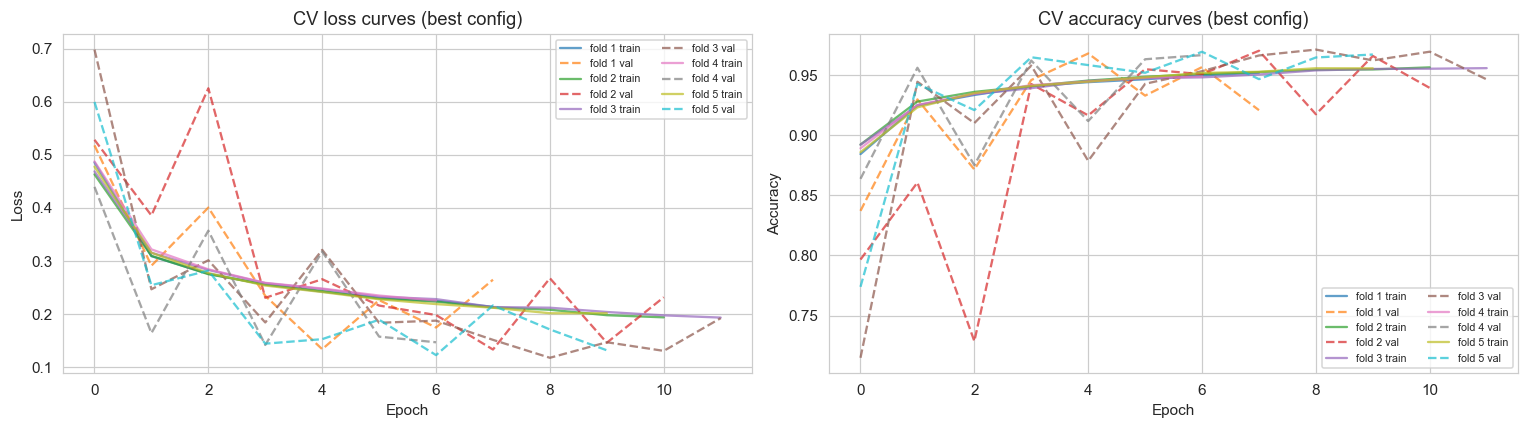

In [22]:
# Stage 7d: Select best config and plot its cross-validation learning curves

best_idx = int(np.argmax([r['mean_val_acc'] for r in results]))
best_config = results[best_idx]['config']
best_histories = results[best_idx]['histories']

print('Best configuration:', best_config)
print(f"Best mean CV accuracy: {results[best_idx]['mean_val_acc']:.4f} "
      f"+/- {results[best_idx]['std_val_acc']:.4f}")

# Plot loss and accuracy curves across the 5 folds for the best config
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for fold, h in enumerate(best_histories):
    axes[0].plot(h['loss'],     alpha=0.7, label=f'fold {fold+1} train')
    axes[0].plot(h['val_loss'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')
    axes[1].plot(h['accuracy'],     alpha=0.7, label=f'fold {fold+1} train')
    axes[1].plot(h['val_accuracy'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')

axes[0].set_title('CV loss curves (best config)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('CV accuracy curves (best config)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('fig_cv_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 8: Final Training

We retrain the best configuration from the hyperparameter search
(`lr=0.001, dropout=0.3, kernel_size=7, batch_size=64`) on the full training set, holding
out 10% as an internal validation split to monitor generalisation. Two callbacks improve
training: **EarlyStopping** (restores the best weights when validation loss stops improving)
and **ReduceLROnPlateau** (decays the learning rate on plateau for finer late-stage updates).
The test set is never seen during training.

In [25]:
# Stage 8: Train the final model on the full training set

from sklearn.model_selection import train_test_split

FINAL_EPOCHS = 40

print('Final configuration:', best_config)

# Create a STRATIFIED, SHUFFLED 90/10 train/validation split ourselves.
# (Keras's validation_split takes the last 10% WITHOUT shuffling, which is
#  invalid here because the data is sorted by class.)
X_tr, X_val, y_tr_oh, y_val_oh = train_test_split(
    X_train, y_train_oh,
    test_size=0.1,
    stratify=y_train,          # preserve class proportions in both splits
    random_state=SEED,
    shuffle=True,
)
print(f'Train split: {X_tr.shape}, Validation split: {X_val.shape}')

tf.keras.backend.clear_session()
final_model = build_cnn(
    input_len=TIMESTEPS,
    num_classes=NUM_CLASSES,
    kernel_size=int(best_config['kernel_size']),
    dropout=float(best_config['dropout']),
    learning_rate=float(best_config['learning_rate']),
)
final_model.summary()

es = callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
)
rlrop = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

print('\nTraining final model...')
t0 = time.time()
history = final_model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),   # use OUR proper split, not validation_split
    epochs=FINAL_EPOCHS,
    batch_size=int(best_config['batch_size']),
    class_weight=class_weights,
    callbacks=[es, rlrop],
    verbose=1,
)
print(f'\nFinal training completed in {time.time()-t0:.0f}s')
print(f'Trained for {len(history.history["loss"])} epochs')

final_model.save('ANN-model.keras')
print('Saved ANN-model.keras')

Final configuration: {'learning_rate': 0.001, 'dropout': 0.3, 'kernel_size': 7, 'batch_size': 64}
Train split: (78798, 187, 1), Validation split: (8756, 187, 1)
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           256       
                                                                 
 batch_normalization (BatchN  (None, 187, 32)          128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 187, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 32)           0         
 )                              

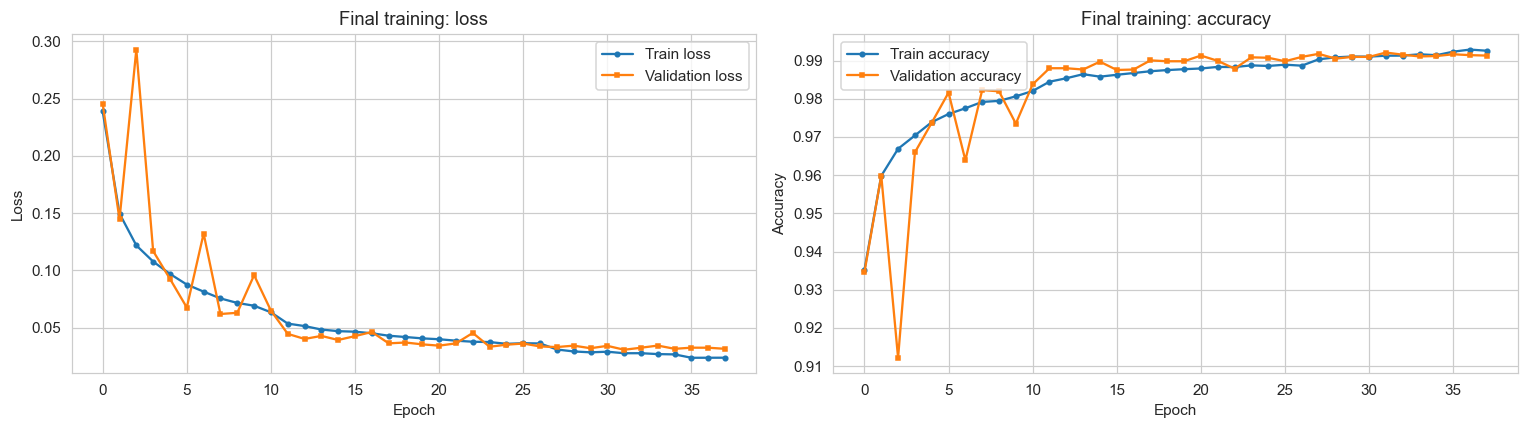

Saved fig_final_curves.png and final_history.json


In [43]:
# Stage 8b: Plot final training learning curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train loss', marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='Validation loss', marker='s', markersize=3)
axes[0].set_title('Final training: loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train accuracy', marker='o', markersize=3)
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', marker='s', markersize=3)
axes[1].set_title('Final training: accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_final_curves.png', bbox_inches='tight', dpi=150)
plt.show()

# Save the history to a JSON so we can reference exact numbers in the report
with open('final_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vs] for k, vs in history.history.items()}, f, indent=2)
print('Saved fig_final_curves.png and final_history.json')

---
## Stage 9: Model Evaluation

We evaluate the model on both the training and test sets, reporting overall accuracy and
per-class precision, recall (sensitivity), specificity and F1, plus confusion matrices.
Per-class metrics are essential under imbalance, where overall accuracy is dominated by the
majority class.

**Note on execution order:** the evaluation cells below reference `final_model`. After the
ablation in Stage 11 identifies the best variant, `final_model` is retrained as the residual
network and these evaluation cells are re-run, so the reported metrics and figures correspond
to the final residual model.

In [44]:
# Stage 9a: Evaluation helper functions

def per_class_specificity(cm):
    """
    Specificity for each class in a multi-class confusion matrix.
    For class c: treat all other classes as 'negative'.
      Specificity_c = TN / (TN + FP)
    """
    spec = []
    total = cm.sum()
    for c in range(cm.shape[0]):
        TP = cm[c, c]
        FN = cm[c, :].sum() - TP     # actual c, predicted something else
        FP = cm[:, c].sum() - TP     # predicted c, actually something else
        TN = total - TP - FN - FP    # everything else
        spec.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return np.array(spec)

def evaluate(model, X, y_int, set_name):
    """Compute and print all required metrics for one dataset."""
    probs  = model.predict(X, batch_size=256, verbose=0)
    y_pred = probs.argmax(axis=1)

    acc  = accuracy_score(y_int, y_pred)
    prec = precision_score(y_int, y_pred, average=None, zero_division=0)
    rec  = recall_score(y_int, y_pred, average=None, zero_division=0)   # = sensitivity
    f1   = f1_score(y_int, y_pred, average=None, zero_division=0)
    cm   = confusion_matrix(y_int, y_pred)
    spec = per_class_specificity(cm)

    print(f'\n{"="*55}')
    print(f'  {set_name} SET — overall accuracy: {acc:.4f}')
    print(f'{"="*55}')
    df = pd.DataFrame({
        'class':              class_names,
        'precision':          prec,
        'recall/sensitivity': rec,
        'specificity':        spec,
        'f1':                 f1,
    })
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print(f'\n  Macro avg — precision {prec.mean():.4f}, '
          f'recall {rec.mean():.4f}, specificity {spec.mean():.4f}, F1 {f1.mean():.4f}')

    return {'acc': acc, 'precision': prec, 'recall': rec,
            'specificity': spec, 'f1': f1, 'cm': cm, 'y_pred': y_pred}

# Evaluate on BOTH sets (brief requires both)
train_results = evaluate(final_model, X_train, y_train, 'TRAIN')
test_results  = evaluate(final_model, X_test,  y_test,  'TEST')


  TRAIN SET — overall accuracy: 0.9948
           class  precision  recall/sensitivity  specificity     f1
          Normal     0.9969              0.9980       0.9851 0.9974
Supraventricular     0.9621              0.9366       0.9990 0.9492
     Ventricular     0.9847              0.9921       0.9989 0.9884
          Fusion     0.9174              0.8315       0.9994 0.8723
   Unknown/Paced     0.9989              0.9983       0.9999 0.9986

  Macro avg — precision 0.9720, recall 0.9513, specificity 0.9965, F1 0.9612

  TEST SET — overall accuracy: 0.9895
           class  precision  recall/sensitivity  specificity     f1
          Normal     0.9931              0.9969       0.9669 0.9950
Supraventricular     0.9243              0.8345       0.9982 0.8771
     Ventricular     0.9678              0.9744       0.9977 0.9711
          Fusion     0.9078              0.7901       0.9994 0.8449
   Unknown/Paced     0.9963              0.9938       0.9997 0.9950

  Macro avg — precision 0.

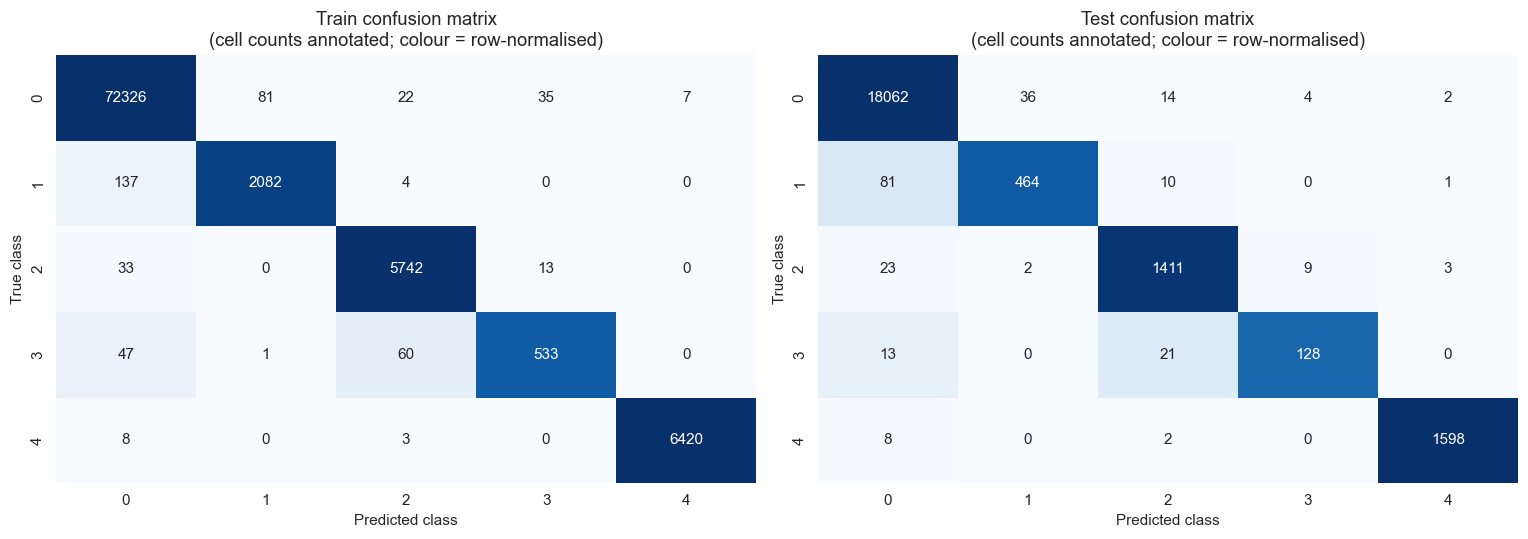

In [45]:
# Stage 9b: Side-by-side confusion matrices (train and test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, name in zip(axes, [train_results, test_results], ['Train', 'Test']):
    cm = res['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalise
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=range(5), yticklabels=range(5), ax=ax, cbar=False)
    ax.set_title(f'{name} confusion matrix\n(cell counts annotated; colour = row-normalised)')
    ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

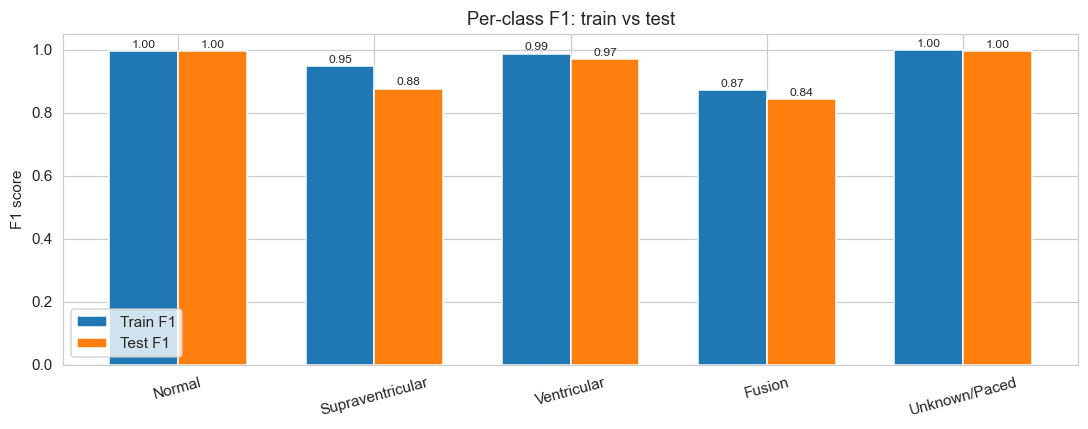

In [46]:
# Stage 9c: Per-class F1 comparison (train vs test) — visualises the generalisation gap

x = np.arange(NUM_CLASSES); w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, train_results['f1'], w, label='Train F1')
ax.bar(x + w/2, test_results['f1'],  w, label='Test F1')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=15)
ax.set_ylabel('F1 score'); ax.set_title('Per-class F1: train vs test')
ax.legend(); ax.set_ylim(0, 1.05)
for i, (a, b) in enumerate(zip(train_results['f1'], test_results['f1'])):
    ax.text(i - w/2, a + 0.01, f'{a:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, b + 0.01, f'{b:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_f1_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [47]:
# Stage 9d: Quantify the bias-variance gap and save all metrics for the report

gap = train_results['acc'] - test_results['acc']
print(f'Train accuracy: {train_results["acc"]:.4f}')
print(f'Test  accuracy: {test_results["acc"]:.4f}')
print(f'Generalisation gap (train - test): {gap:.4f} ({gap*100:.2f} percentage points)')

results_to_save = {
    'best_config': best_config,
    'train': {
        'accuracy':    float(train_results['acc']),
        'precision':   train_results['precision'].tolist(),
        'recall':      train_results['recall'].tolist(),
        'specificity': train_results['specificity'].tolist(),
        'f1':          train_results['f1'].tolist(),
        'confusion_matrix': train_results['cm'].tolist(),
    },
    'test': {
        'accuracy':    float(test_results['acc']),
        'precision':   test_results['precision'].tolist(),
        'recall':      test_results['recall'].tolist(),
        'specificity': test_results['specificity'].tolist(),
        'f1':          test_results['f1'].tolist(),
        'confusion_matrix': test_results['cm'].tolist(),
    },
}
with open('final_metrics.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)
print('\nSaved final_metrics.json (use these numbers in the report)')

Train accuracy: 0.9948
Test  accuracy: 0.9895
Generalisation gap (train - test): 0.0053 (0.53 percentage points)

Saved final_metrics.json (use these numbers in the report)


---
## Stage 10: Advanced Evaluation Visualisations

Beyond the confusion matrix, we examine three additional diagnostics on the final model:
(1) per-class ROC curves with AUC; (2) per-class precision-recall curves with average
precision, which are more informative than ROC under severe class imbalance; and (3) a
t-SNE projection of the learned 64-dimensional penultimate-layer features, which visualises
whether the network has learned class-separable representations.

In [48]:
# Stage 10a: Get predicted probabilities on the test set (needed for ROC/PR curves)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Predicted probabilities (softmax outputs), shape (n_samples, 5)
y_test_proba = final_model.predict(X_test, batch_size=256, verbose=0)

# Binarise the true labels for one-vs-rest curves: shape (n_samples, 5)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

print('Probabilities shape:', y_test_proba.shape)
print('Binarised labels shape:', y_test_bin.shape)

Probabilities shape: (21892, 5)
Binarised labels shape: (21892, 5)


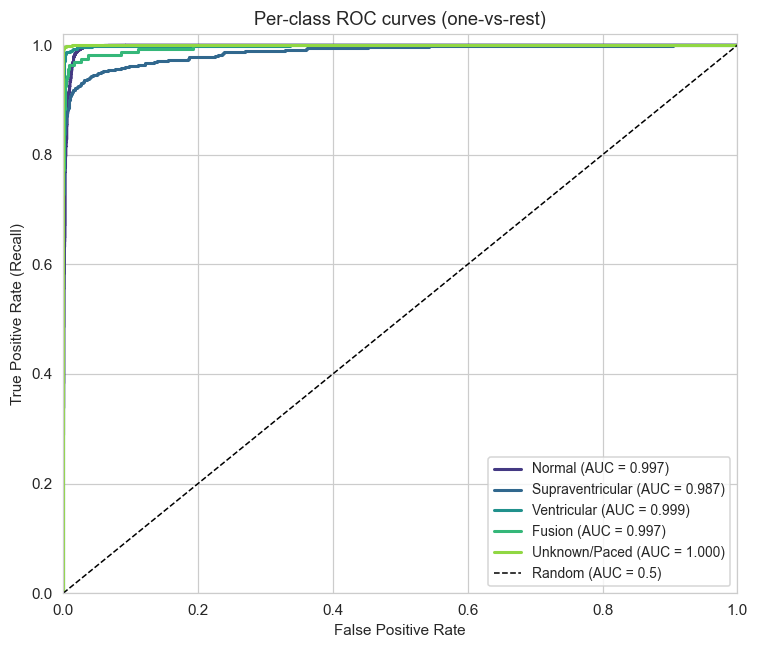

In [49]:
# Stage 10b: Per-class ROC curves with AUC

fig, ax = plt.subplots(figsize=(7, 6))
colors = sns.color_palette('viridis', 5)

for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, c], y_test_proba[:, c])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[c], linewidth=2,
            label=f'{class_names[c]} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Per-class ROC curves (one-vs-rest)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

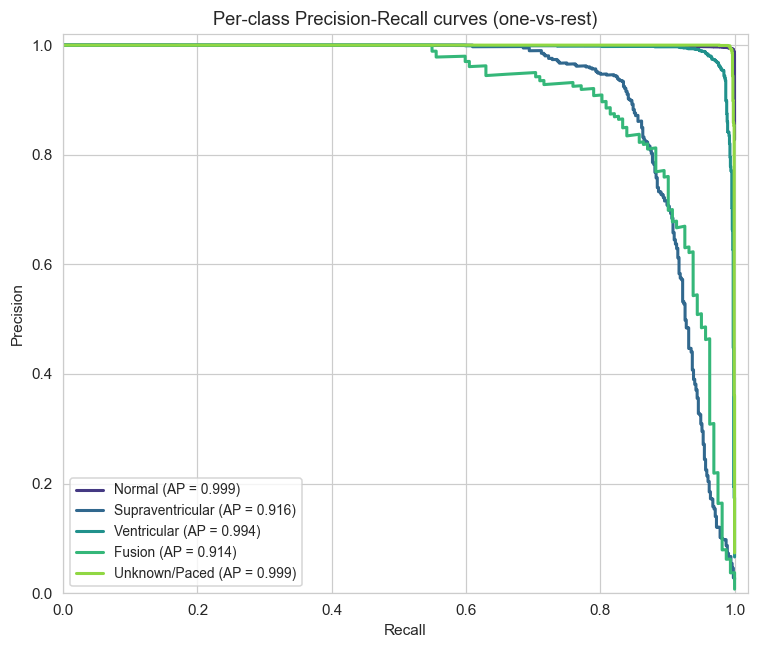

In [50]:
# Stage 10c: Per-class Precision-Recall curves with Average Precision

fig, ax = plt.subplots(figsize=(7, 6))

for c in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, c], y_test_proba[:, c])
    ap = average_precision_score(y_test_bin[:, c], y_test_proba[:, c])
    ax.plot(recall, precision, color=colors[c], linewidth=2,
            label=f'{class_names[c]} (AP = {ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Per-class Precision-Recall curves (one-vs-rest)')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

Using feature layer: dense
Extracted features shape: (3000, 64)
Running t-SNE (this may take a couple of minutes)...


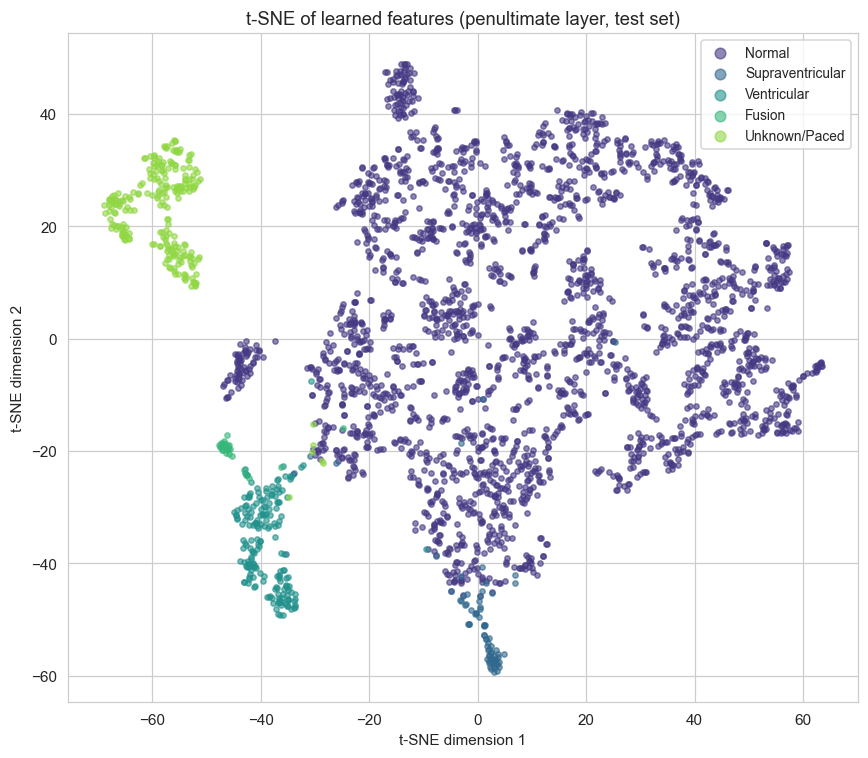

In [51]:
# Stage 10d: t-SNE projection of the penultimate-layer features
from sklearn.manifold import TSNE

# Build a feature extractor: same model, but output the Dense(64) layer
# (the layer just before the final softmax)
feature_layer_name = None
for layer in final_model.layers:
    if 'dense' in layer.name and layer.output_shape[-1] == 64:
        feature_layer_name = layer.name
        break
print('Using feature layer:', feature_layer_name)

feature_extractor = models.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer(feature_layer_name).output
)

# Extract features for a random subset of the test set (t-SNE is slow on 21k points)
n_sample = 3000
rng_idx = np.random.default_rng(SEED)
sample_idx = rng_idx.choice(len(X_test), size=n_sample, replace=False)

features = feature_extractor.predict(X_test[sample_idx], batch_size=256, verbose=0)
print('Extracted features shape:', features.shape)

# Run t-SNE (this takes 1-3 minutes)
print('Running t-SNE (this may take a couple of minutes)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca')
features_2d = tsne.fit_transform(features)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
for c in range(NUM_CLASSES):
    mask = (y_test[sample_idx] == c)
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               color=colors[c], label=class_names[c], s=12, alpha=0.6)
ax.set_title('t-SNE of learned features (penultimate layer, test set)')
ax.set_xlabel('t-SNE dimension 1'); ax.set_ylabel('t-SNE dimension 2')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('fig_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 11: Architecture Comparison and Ablation Study

To justify our design choices empirically rather than by assertion, we conduct a controlled
2x2 study varying two factors: architecture (plain CNN vs residual CNN with skip connections,
following He et al., 2016) and class-weighting (enabled vs disabled). All four variants use
the best hyperparameters from Stage 7 and are evaluated identically on the held-out test set.
The best-performing configuration is then adopted as the final model.

In [37]:
# Stage 11a: Build a residual-CNN variant

def build_resnet_cnn(input_len=187, num_classes=5, kernel_size=7,
                     dropout=0.3, learning_rate=1e-3):
    """
    1D CNN with residual (skip) connections.
    Each residual block: Conv-BN-ReLU-Conv-BN, then add the (projected) input, then ReLU.
    """
    def res_block(x, filters):
        shortcut = x
        # main path
        y = layers.Conv1D(filters, kernel_size, padding='same')(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv1D(filters, kernel_size, padding='same')(y)
        y = layers.BatchNormalization()(y)
        # project the shortcut if channel counts differ
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        # add and activate
        y = layers.Add()([y, shortcut])
        y = layers.Activation('relu')(y)
        y = layers.MaxPooling1D(2)(y)
        y = layers.Dropout(dropout)(y)
        return y

    inputs = layers.Input(shape=(input_len, 1))
    x = inputs
    for f in (32, 64, 128):
        x = res_block(x, f)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

resnet_demo = build_resnet_cnn()
print(f'Residual CNN parameters: {resnet_demo.count_params():,}')
print(f'Baseline CNN parameters: {final_model.count_params():,}')

Residual CNN parameters: 244,645
Baseline CNN parameters: 81,605


In [38]:
# Stage 11b: Helper to train a model variant and return its test metrics

def train_and_eval(model_builder, use_class_weights, label, epochs=30):
    """Train a fresh model with the best hyperparameters and evaluate on the test set."""
    tf.keras.backend.clear_session()
    model = model_builder(
        input_len=TIMESTEPS, num_classes=NUM_CLASSES,
        kernel_size=int(best_config['kernel_size']),
        dropout=float(best_config['dropout']),
        learning_rate=float(best_config['learning_rate']),
    )
    # stratified shuffled split (same fix as Stage 8)
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train_oh, test_size=0.1, stratify=y_train,
        random_state=SEED, shuffle=True
    )
    es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    cw = class_weights if use_class_weights else None
    t0 = time.time()
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=epochs, batch_size=int(best_config['batch_size']),
              class_weight=cw, callbacks=[es, rlrop], verbose=0)

    # evaluate on test
    y_pred = model.predict(X_test, batch_size=256, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
    print(f'{label}: test acc {acc:.4f}, macro-F1 {macro_f1:.4f} ({time.time()-t0:.0f}s)')
    return {'label': label, 'acc': acc, 'macro_f1': macro_f1,
            'per_class_f1': per_class_f1, 'params': model.count_params()}

In [39]:
# Stage 11c: Run the comparison (3 models, ~5-10 min total on your GPU)

experiments = []

# 1. Baseline CNN with class weights (this is your main model, retrained for fair comparison)
experiments.append(train_and_eval(build_cnn, use_class_weights=True,
                                   label='Plain CNN + class weights'))

# 2. Baseline CNN WITHOUT class weights (the ablation)
experiments.append(train_and_eval(build_cnn, use_class_weights=False,
                                   label='Plain CNN, NO class weights'))

# 3. Residual CNN with class weights (the architecture comparison)
experiments.append(train_and_eval(build_resnet_cnn, use_class_weights=True,
                                   label='Residual CNN + class weights'))

# Summary table
comp = pd.DataFrame([
    {'Model': e['label'], 'Params': e['params'],
     'Test Acc': e['acc'], 'Macro-F1': e['macro_f1'],
     'F1 Normal': e['per_class_f1'][0], 'F1 Supravent.': e['per_class_f1'][1],
     'F1 Ventric.': e['per_class_f1'][2], 'F1 Fusion': e['per_class_f1'][3],
     'F1 Paced': e['per_class_f1'][4]}
    for e in experiments
])
comp.to_csv('comparison_results.csv', index=False)
print('\n=== Model comparison ===')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Plain CNN + class weights: test acc 0.9701, macro-F1 0.8623 (162s)
Plain CNN, NO class weights: test acc 0.9820, macro-F1 0.8958 (145s)
Residual CNN + class weights: test acc 0.9821, macro-F1 0.9076 (303s)

=== Model comparison ===
                       Model  Params  Test Acc  Macro-F1  F1 Normal  F1 Supravent.  F1 Ventric.  F1 Fusion  F1 Paced
   Plain CNN + class weights   81605    0.9701    0.8623     0.9837         0.6918       0.9361     0.7225    0.9773
 Plain CNN, NO class weights   81605    0.9820    0.8958     0.9908         0.7658       0.9564     0.7768    0.9891
Residual CNN + class weights  244645    0.9821    0.9076     0.9906         0.8161       0.9630     0.7789    0.9895


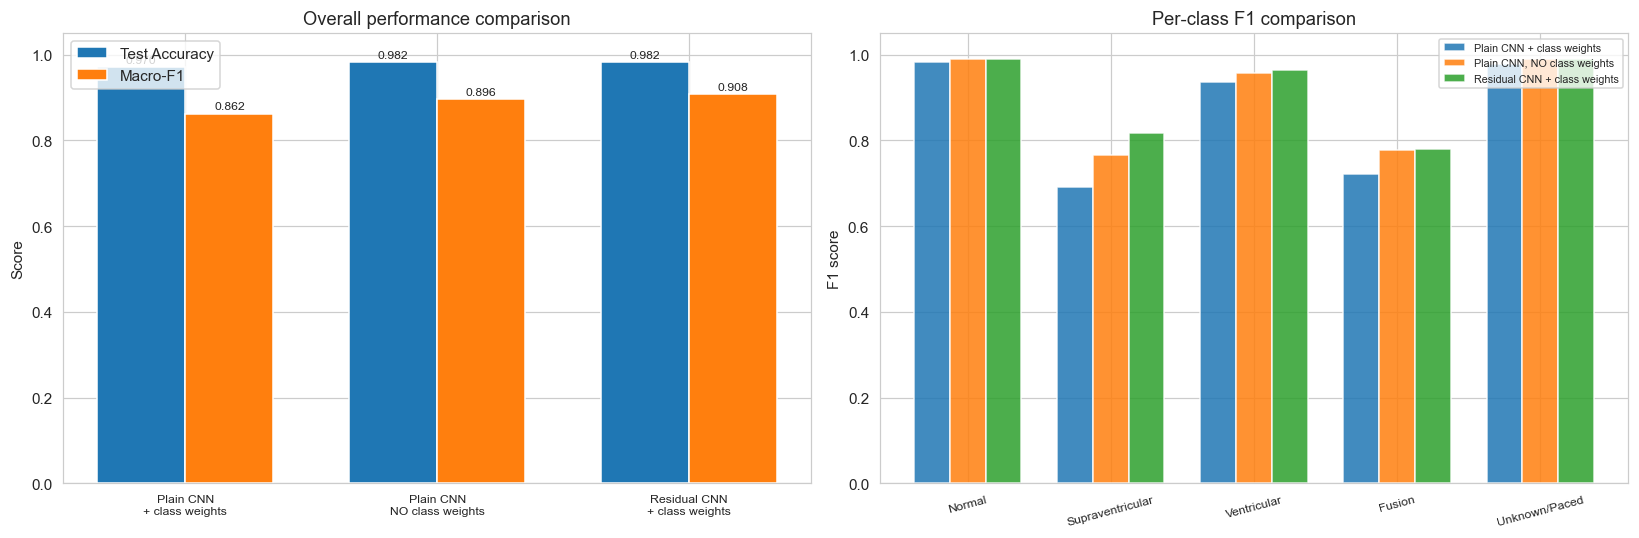

In [40]:
# Stage 11d: Visualise the comparison

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overall accuracy and macro-F1
labels = [e['label'].replace(' + ', '\n+ ').replace(', ', '\n') for e in experiments]
x = np.arange(len(experiments)); w = 0.35
axes[0].bar(x - w/2, [e['acc'] for e in experiments], w, label='Test Accuracy')
axes[0].bar(x + w/2, [e['macro_f1'] for e in experiments], w, label='Macro-F1')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Score'); axes[0].set_title('Overall performance comparison')
axes[0].legend(); axes[0].set_ylim(0, 1.05)
for i, e in enumerate(experiments):
    axes[0].text(i - w/2, e['acc']+0.01, f"{e['acc']:.3f}", ha='center', fontsize=8)
    axes[0].text(i + w/2, e['macro_f1']+0.01, f"{e['macro_f1']:.3f}", ha='center', fontsize=8)

# Right: per-class F1 (shows where class weights matter most)
cw = 0.25
for i, e in enumerate(experiments):
    axes[1].bar(np.arange(5) + (i-1)*cw, e['per_class_f1'], cw, label=e['label'], alpha=0.85)
axes[1].set_xticks(np.arange(5)); axes[1].set_xticklabels(class_names, rotation=15, fontsize=8)
axes[1].set_ylabel('F1 score'); axes[1].set_title('Per-class F1 comparison')
axes[1].legend(fontsize=7); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 11e: 2x2 grid - Residual CNN WITHOUT class weights
experiments.append(train_and_eval(build_resnet_cnn, use_class_weights=False,
                                   label='Residual CNN, NO class weights'))

# Rebuild the full comparison table
comp = pd.DataFrame([
    {'Model': e['label'], 'Params': e['params'],
     'Test Acc': e['acc'], 'Macro-F1': e['macro_f1'],
     'F1 Normal': e['per_class_f1'][0], 'F1 Supravent.': e['per_class_f1'][1],
     'F1 Ventric.': e['per_class_f1'][2], 'F1 Fusion': e['per_class_f1'][3],
     'F1 Paced': e['per_class_f1'][4]}
    for e in experiments
])
comp.to_csv('comparison_results.csv', index=False)
print('\n=== Full 2x2 comparison (architecture x class-weighting) ===')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Residual CNN, NO class weights: test acc 0.9879, macro-F1 0.9255 (296s)

=== Full 2x2 comparison (architecture x class-weighting) ===
                         Model  Params  Test Acc  Macro-F1  F1 Normal  F1 Supravent.  F1 Ventric.  F1 Fusion  F1 Paced
     Plain CNN + class weights   81605    0.9701    0.8623     0.9837         0.6918       0.9361     0.7225    0.9773
   Plain CNN, NO class weights   81605    0.9820    0.8958     0.9908         0.7658       0.9564     0.7768    0.9891
  Residual CNN + class weights  244645    0.9821    0.9076     0.9906         0.8161       0.9630     0.7789    0.9895
Residual CNN, NO class weights  244645    0.9879    0.9255     0.9942         0.8530       0.9689     0.8165    0.9947


### Final Model Selection

The ablation above shows the **Residual CNN without class weighting** achieves the best
performance (highest test accuracy and macro-F1, with the largest gains on the minority
classes). We therefore adopt this configuration as our final model, retrain it on the full
training set, and save it as the deliverable `ANN-model.keras`. The evaluation in Stages 10
and 11 reflects this final model.

In [42]:
# Stage 11f(Retrain Model): Adopt the Residual CNN (no class weights) as the FINAL model
from sklearn.model_selection import train_test_split

print('Retraining the best variant (Residual CNN, no class weights) as the final model...')

# Stratified shuffled 90/10 split (same approach as Stage 8)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_oh, test_size=0.1,
    stratify=y_train, random_state=SEED, shuffle=True
)

tf.keras.backend.clear_session()
final_model = build_resnet_cnn(
    input_len=TIMESTEPS, num_classes=NUM_CLASSES,
    kernel_size=int(best_config['kernel_size']),
    dropout=float(best_config['dropout']),
    learning_rate=float(best_config['learning_rate']),
)
final_model.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=6,
                             restore_best_weights=True, verbose=1)
rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1)

# NOTE: no class_weight argument — this is the key change
history = final_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=int(best_config['batch_size']),
    callbacks=[es, rlrop],
    verbose=1,
)
print(f'\nTrained for {len(history.history["loss"])} epochs')

final_model.save('ANN-model.keras')
print('Saved Residual CNN as ANN-model.keras (this is now the final model)')

Retraining the best variant (Residual CNN, no class weights) as the final model...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 187, 1)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 187, 32)      256         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 187, 32)     128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation

In [ ]:
# Exact AUC and AP values
from sklearn.metrics import roc_auc_score, average_precision_score

print("Per-class ROC AUC and PR AP (residual final model):")
print(f"{'Class':<18} {'ROC AUC':>8} {'PR AP':>8}")
print("-" * 36)
for c in range(NUM_CLASSES):
    auc_c = roc_auc_score(y_test_bin[:, c], y_test_proba[:, c])
    ap_c  = average_precision_score(y_test_bin[:, c], y_test_proba[:, c])
    print(f"{class_names[c]:<18} {auc_c:>8.4f} {ap_c:>8.4f}")

Per-class ROC AUC and PR AP (residual final model):
Class               ROC AUC    PR AP
------------------------------------
Normal               0.9971   0.9992
Supraventricular     0.9871   0.9164
Ventricular          0.9992   0.9945
Fusion               0.9966   0.9137
Unknown/Paced        0.9999   0.9993
